# Bivariate Exploratory Data Analysis

In this notebook I will perform bivariate analysis to understand the relationship between features and the target variable (`is_cancelled`).

## Objectives
1. Analyze each feature's relationship with cancellation
2. Identify the strongest predictors
3. Discover patterns that can inform feature engineering
4. Validate hypotheses from univariate analysis

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
data = pd.read_parquet("../data/bronze/clean_dataset.parquet", engine='pyarrow')
data = data.sort_values(["date", "time"]).reset_index(drop=True)

print(f"Dataset shape: {data.shape}")
print(f"Cancellation rate: {data['is_cancelled'].mean():.2%}")
data.head()

Dataset shape: (150000, 13)
Cancellation rate: 32.00%


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,booking_value,ride_distance,payment_method,is_cancelled
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.900002,99.0,37.980000,Cash,0.0
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.100000,114.0,39.290001,Uber Wallet,0.0
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,NaN,1.0
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,NaN,1.0
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,NaN,1.0


In [3]:
# Prepare data - remove leaking columns and create temporal features
df = data.copy()

# Create datetime and temporal features
df['datetime'] = pd.to_datetime(df['date'] + " " + df['time'], format="%Y-%m-%d %H:%M:%S")
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Remove features that leak information (only available after booking outcome)
# These have NaN only for cancelled bookings
leaking_cols = ["avg_ctat", "booking_value", "ride_distance", "payment_method"]
df.drop(columns=leaking_cols, inplace=True)

# Create VTAT bins
bins = [0, 5, 10, 15, 20]
labels = ["0-5", "5-10", "10-15", "15-20"]
df["vtat_bucket"] = pd.cut(df["avg_vtat"], bins=bins, labels=labels).astype("category")

print(f"Columns available for analysis: {df.columns.tolist()}")
df.head()

Columns available for analysis: ['date', 'time', 'booking_id', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat', 'is_cancelled', 'datetime', 'hour', 'dayofweek', 'month', 'is_weekend', 'vtat_bucket']


,date,time,booking_id,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,is_cancelled,datetime,hour,dayofweek,month,is_weekend,vtat_bucket
0,2024-01-01,00:19:34,CNR4352144,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,0.0,2024-01-01 00:19:34,0,0,1,0,10-15
1,2024-01-01,01:35:18,CNR9147645,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,0.0,2024-01-01 01:35:18,1,0,1,0,5-10
2,2024-01-01,01:37:50,CNR1009222,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,1.0,2024-01-01 01:37:50,1,0,1,0,5-10
3,2024-01-01,01:48:03,CNR2740479,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,1.0,2024-01-01 01:48:03,1,0,1,0,5-10
4,2024-01-01,01:49:56,CNR7650148,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,1.0,2024-01-01 01:49:56,1,0,1,0,5-10



## 1. VTAT (Wait Time) vs Target

Higher wait times lead to more cancellations??

In [4]:
# Statistical test: Point-biserial correlation
vtat_clean = df.dropna(subset=['avg_vtat'])
corr, p_value = stats.pointbiserialr(vtat_clean['is_cancelled'], vtat_clean['avg_vtat'])

print("VTAT vs CANCELLATION - STATISTICAL TEST")
print("-" * 60)
print(f"\nPoint-biserial correlation: {corr:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"\nInterpretation: {'Significant' if p_value < 0.05 else 'Not significant'} correlation")

VTAT vs CANCELLATION - STATISTICAL TEST
------------------------------------------------------------

Point-biserial correlation: 0.0721
P-value: 5.36e-160

Interpretation: Significant correlation


In [5]:
# Compare VTAT distributions
vtat_completed = df[df['is_cancelled'] == 0]['avg_vtat'].dropna()
vtat_cancelled = df[df['is_cancelled'] == 1]['avg_vtat'].dropna()

print("\nVTAT Statistics by Outcome:")
print("-" * 40)
print(f"Completed rides: Mean = {vtat_completed.mean():.2f} min, Median = {vtat_completed.median():.2f} min")
print(f"Cancelled rides: Mean = {vtat_cancelled.mean():.2f} min, Median = {vtat_cancelled.median():.2f} min")
print(f"Difference in means: {vtat_cancelled.mean() - vtat_completed.mean():.2f} min")

# T-test
t_stat, t_pvalue = stats.ttest_ind(vtat_completed, vtat_cancelled)
print(f"\nT-test: t = {t_stat:.2f}, p = {t_pvalue:.2e}")


VTAT Statistics by Outcome:
----------------------------------------
Completed rides: Mean = 8.29 min, Median = 8.20 min
Cancelled rides: Mean = 8.90 min, Median = 8.40 min
Difference in means: 0.61 min

T-test: t = -26.99, p = 5.35e-160


In [6]:
# Cancellation rate by VTAT bucket
vtat_analysis = df.groupby('vtat_bucket', observed=True).agg({
    'is_cancelled': ['mean', 'count', 'sum']
}).round(4)
vtat_analysis.columns = ['Cancellation Rate', 'Total Bookings', 'Cancellations']

print("\nCancellation Rate by VTAT Bucket:")
print(vtat_analysis)


Cancellation Rate by VTAT Bucket:
             Cancellation Rate  Total Bookings  Cancellations
vtat_bucket                                                  
0-5                     0.1987           31311         6221.0
5-10                    0.3083           59896        18467.0
10-15                   0.2075           44772         9291.0
15-20                   1.0000            3521         3521.0


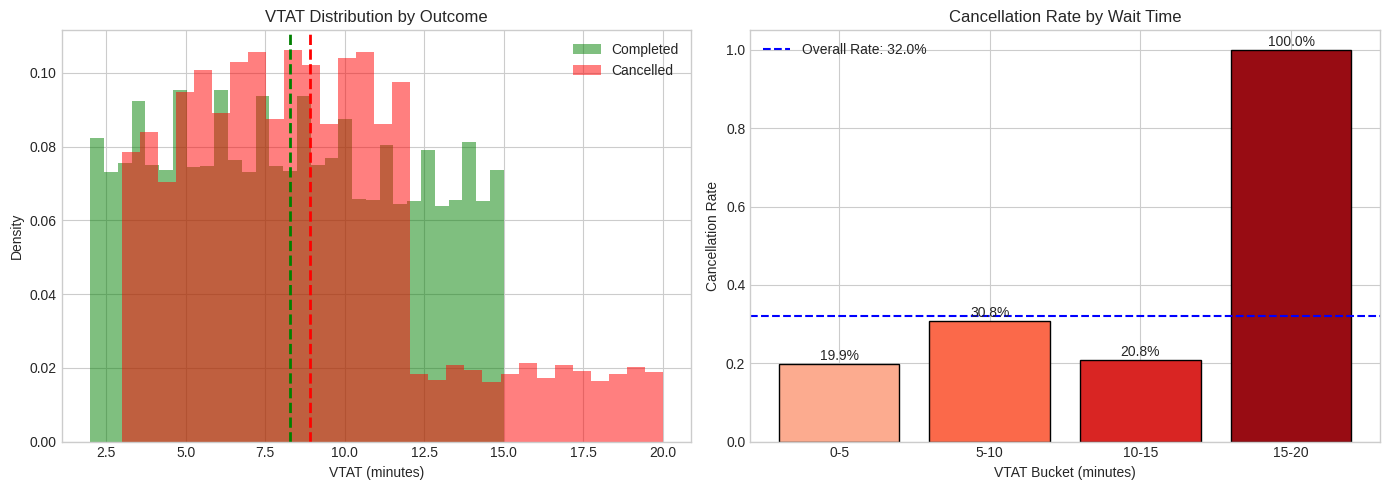

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison of distributions
ax1 = axes[0]
ax1.hist(vtat_completed, bins=30, alpha=0.5, label='Completed', color='green', density=True)
ax1.hist(vtat_cancelled, bins=30, alpha=0.5, label='Cancelled', color='red', density=True)
ax1.axvline(vtat_completed.mean(), color='green', linestyle='--', linewidth=2)
ax1.axvline(vtat_cancelled.mean(), color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('VTAT (minutes)')
ax1.set_ylabel('Density')
ax1.set_title('VTAT Distribution by Outcome')
ax1.legend()

# Cancellation rate by waiting time bucket
ax2 = axes[1]
vtat_rates = df.groupby('vtat_bucket', observed=True)['is_cancelled'].mean()
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(vtat_rates)))
bars = ax2.bar(vtat_rates.index.astype(str), vtat_rates.values, color=colors, edgecolor='black')
ax2.axhline(y=df['is_cancelled'].mean(), color='blue', linestyle='--', 
            label=f'Overall Rate: {df["is_cancelled"].mean():.1%}')
ax2.set_xlabel('VTAT Bucket (minutes)')
ax2.set_ylabel('Cancellation Rate')
ax2.set_title('Cancellation Rate by Wait Time')
ax2.legend()

for bar, rate in zip(bars, vtat_rates.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{rate:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

VTAT > 15 minutes shows 100% cancellation rate. This is a critical threshold for intervention.

## 2. Vehicle Type vs Target

In [8]:
# Cancellation rate by vehicle type
vehicle_analysis = df.groupby('vehicle_type', observed=True).agg({
    'is_cancelled': ['mean', 'count', 'sum']
}).round(4)
vehicle_analysis.columns = ['Cancellation Rate', 'Total Bookings', 'Cancellations']
vehicle_analysis = vehicle_analysis.sort_values('Cancellation Rate', ascending=False)

print("CANCELLATION RATE BY VEHICLE TYPE")
print("-" * 60)
print(vehicle_analysis)

CANCELLATION RATE BY VEHICLE TYPE
------------------------------------------------------------
               Cancellation Rate  Total Bookings  Cancellations
vehicle_type                                                   
Go Sedan                  0.3251           27141         8823.0
Auto                      0.3208           37419        12004.0
Premier Sedan             0.3200           18111         5796.0
eBike                     0.3198           10557         3376.0
Bike                      0.3178           22517         7155.0
Go Mini                   0.3168           29806         9442.0
Uber XL                   0.3156            4449         1404.0


In [9]:
# Chi-square test for independence
contingency = pd.crosstab(df['vehicle_type'], df['is_cancelled'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square test:")
print(f"  Chi2 = {chi2:.2f}")
print(f"  P-value = {p_value:.2e}")
print(f"  Degrees of freedom = {dof}")
print(f"\nInterpretation: {'Significant' if p_value < 0.05 else 'Not significant'} association")


Chi-square test:
  Chi2 = 5.67
  P-value = 4.61e-01
  Degrees of freedom = 6

Interpretation: Not significant association


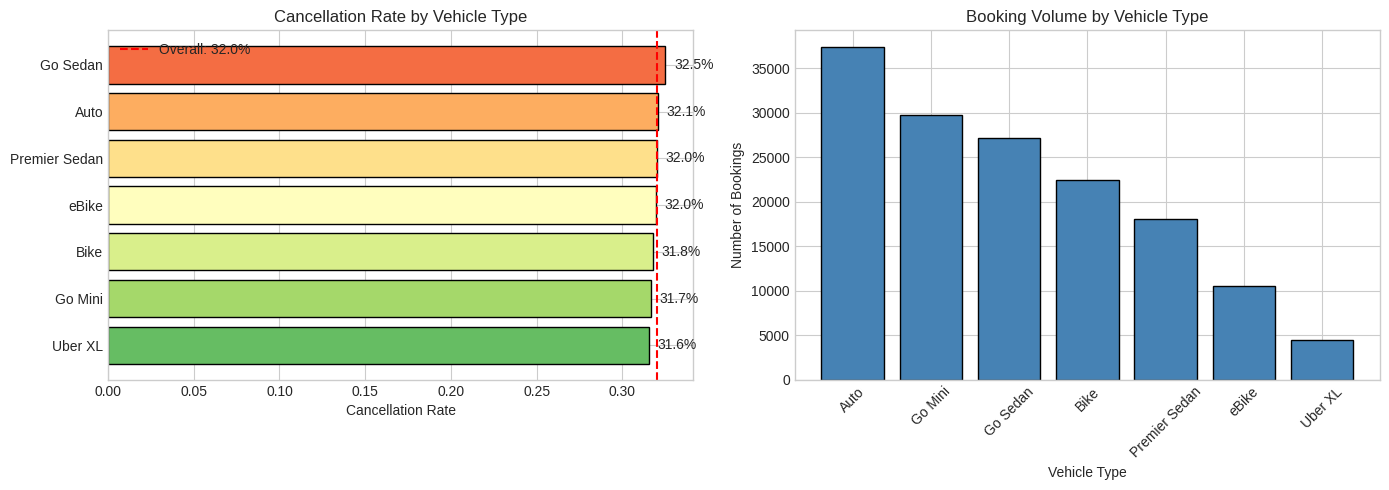

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
vehicle_rates = df.groupby('vehicle_type', observed=True)['is_cancelled'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(vehicle_rates)))
bars = ax1.barh(vehicle_rates.index.astype(str), vehicle_rates.values, color=colors, edgecolor='black')
ax1.axvline(x=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax1.set_xlabel('Cancellation Rate')
ax1.set_title('Cancellation Rate by Vehicle Type')
ax1.legend()

for bar, rate in zip(bars, vehicle_rates.values):
    ax1.text(rate + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{rate:.1%}', va='center', fontsize=10)

ax2 = axes[1]
vehicle_counts = df['vehicle_type'].value_counts()
ax2.bar(vehicle_counts.index.astype(str), vehicle_counts.values, color='steelblue', edgecolor='black')
ax2.set_xlabel('Vehicle Type')
ax2.set_ylabel('Number of Bookings')
ax2.set_title('Booking Volume by Vehicle Type')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

All vehicle types have similar cancellation rates (~32%). Vehicle type alone is NOT a strong predictor.


## 3. Temporal Features vs Target

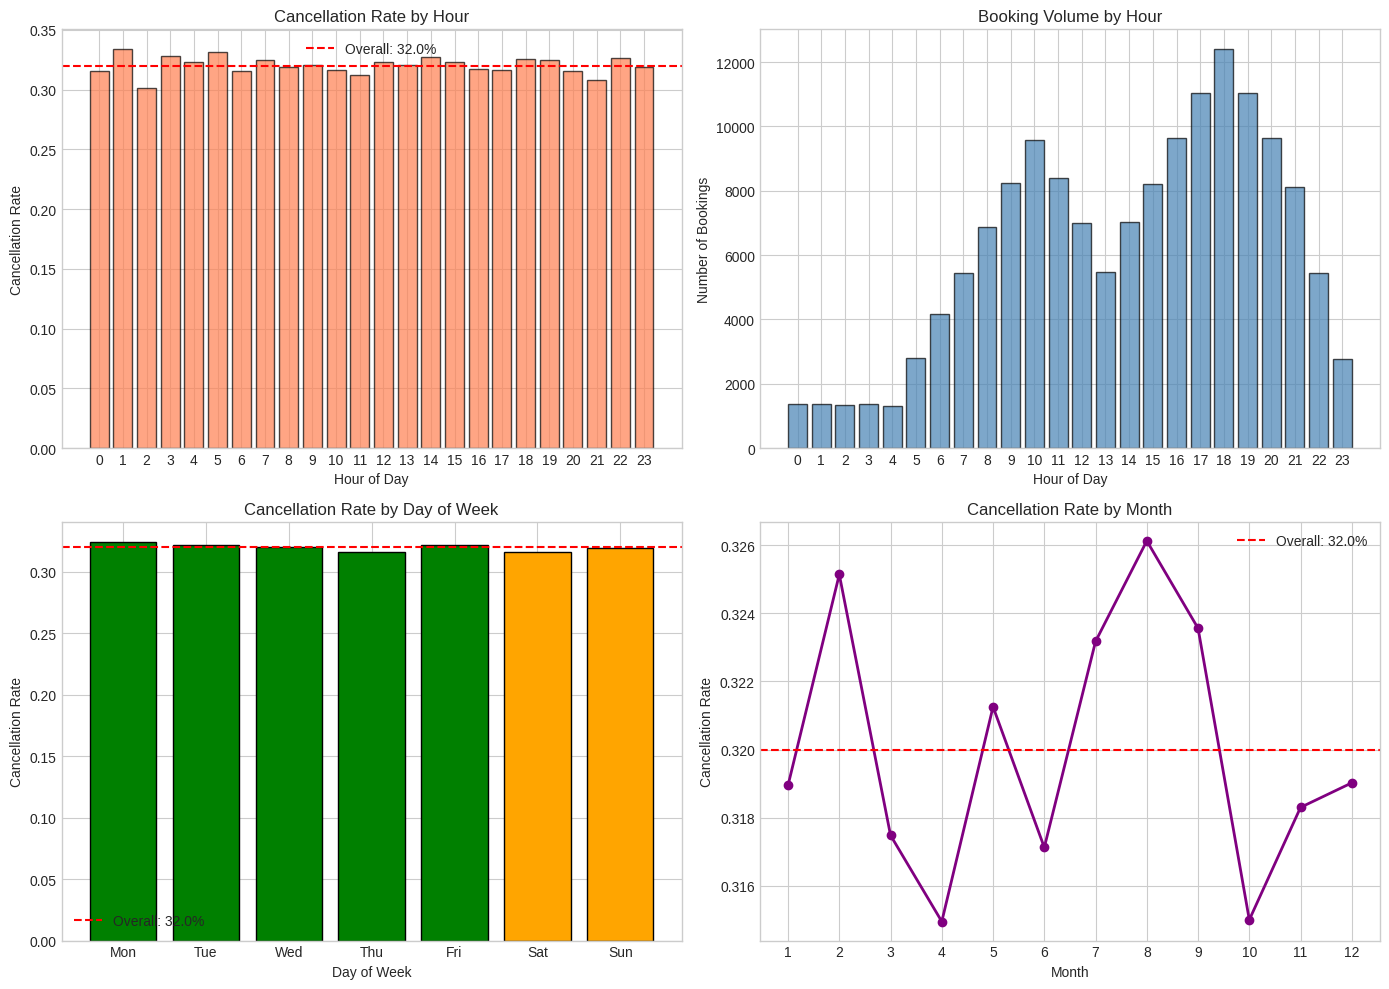

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly cancellation rate
ax1 = axes[0, 0]
hourly_rate = df.groupby('hour')['is_cancelled'].mean()
ax1.bar(hourly_rate.index, hourly_rate.values, color='coral', edgecolor='black', alpha=0.7)
ax1.axhline(y=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Cancellation Rate')
ax1.set_title('Cancellation Rate by Hour')
ax1.legend()
ax1.set_xticks(range(0, 24))

# Hourly volume
ax2 = axes[0, 1]
hourly_count = df.groupby('hour')['is_cancelled'].count()
ax2.bar(hourly_count.index, hourly_count.values, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Number of Bookings')
ax2.set_title('Booking Volume by Hour')
ax2.set_xticks(range(0, 24))

# Day of week
ax3 = axes[1, 0]
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_rate = df.groupby('dayofweek')['is_cancelled'].mean()
colors = ['green' if i < 5 else 'orange' for i in range(7)]
ax3.bar(dow_names, dow_rate.values, color=colors, edgecolor='black')
ax3.axhline(y=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Cancellation Rate')
ax3.set_title('Cancellation Rate by Day of Week')
ax3.legend()

# Monthly trend
ax4 = axes[1, 1]
monthly_rate = df.groupby('month')['is_cancelled'].mean()
ax4.plot(monthly_rate.index, monthly_rate.values, marker='o', linewidth=2, color='purple')
ax4.axhline(y=df['is_cancelled'].mean(), color='red', linestyle='--', 
            label=f'Overall: {df["is_cancelled"].mean():.1%}')
ax4.set_xlabel('Month')
ax4.set_ylabel('Cancellation Rate')
ax4.set_title('Cancellation Rate by Month')
ax4.set_xticks(range(1, 13))
ax4.legend()

plt.tight_layout()
plt.show()

In [12]:
# Weekend vs Weekday
weekend_analysis = df.groupby('is_weekend').agg({
    'is_cancelled': ['mean', 'count']
}).round(4)
weekend_analysis.columns = ['Cancellation Rate', 'Total Bookings']
weekend_analysis.index = ['Weekday', 'Weekend']

print("\nWeekend vs Weekday:")
print(weekend_analysis)


Weekend vs Weekday:
         Cancellation Rate  Total Bookings
Weekday             0.3209          107060
Weekend             0.3177           42940


Cancellation rate is remarkably flat across hours, days, and months. Temporal features alone are weak predictors.


## 4. Location Analysis

In [13]:
# Top pickup locations by cancellation rate
pickup_analysis = df.groupby('pickup_location', observed=True).agg({
    'is_cancelled': ['mean', 'count']
}).round(4)
pickup_analysis.columns = ['Cancellation Rate', 'Total Bookings']

# Filter locations with at least 100 bookings for reliability
pickup_reliable = pickup_analysis[pickup_analysis['Total Bookings'] >= 100]

print("TOP 10 PICKUP LOCATIONS BY CANCELLATION RATE")
print("-" * 60)
print(pickup_reliable.sort_values('Cancellation Rate', ascending=False).head(10))


print("\nBOTTOM 10 PICKUP LOCATIONS BY CANCELLATION RATE")
print("-" * 60)
print(pickup_reliable.sort_values('Cancellation Rate', ascending=True).head(10))

TOP 10 PICKUP LOCATIONS BY CANCELLATION RATE
------------------------------------------------------------
                      Cancellation Rate  Total Bookings
pickup_location                                        
Vinobapuri                       0.3888             823
Akshardham                       0.3659             839
Faridabad Sector 15              0.3598             831
Netaji Subhash Place             0.3566             830
Qutub Minar                      0.3524             823
Vatika Chowk                     0.3517             833
Badshahpur                       0.3514             868
Chhatarpur                       0.3510             829
Karkarduma                       0.3493             836
Shahdara                         0.3488             820

BOTTOM 10 PICKUP LOCATIONS BY CANCELLATION RATE
------------------------------------------------------------
                 Cancellation Rate  Total Bookings
pickup_location                                   
Kanhaiya N

In [14]:
print(f"\nUnique pickup locations: {df['pickup_location'].nunique()}")
print(f"Unique drop locations: {df['drop_location'].nunique()}\n")
print("---"*40)
location_rates = pickup_reliable['Cancellation Rate']
print(f"\nCancellation rate distribution across locations:")
print(f"  Min: {location_rates.min():.2%}")
print(f"  Max: {location_rates.max():.2%}")
print(f"  Mean: {location_rates.mean():.2%}")
print(f"  Std: {location_rates.std():.2%}")


Unique pickup locations: 176
Unique drop locations: 176

------------------------------------------------------------------------------------------------------------------------

Cancellation rate distribution across locations:
  Min: 28.04%
  Max: 38.88%
  Mean: 32.01%
  Std: 1.73%


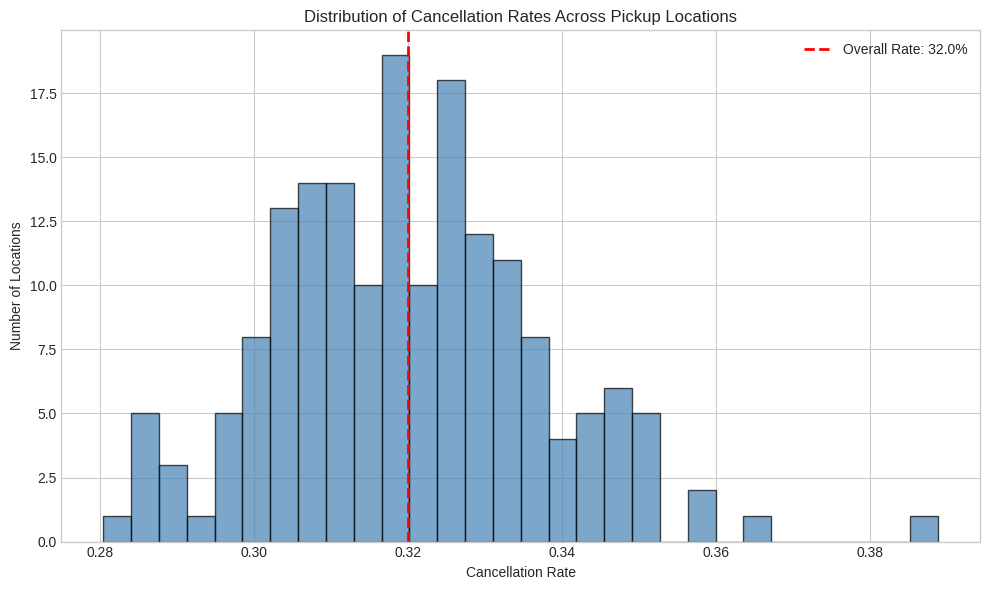

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(location_rates, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=df['is_cancelled'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Overall Rate: {df["is_cancelled"].mean():.1%}')
ax.set_xlabel('Cancellation Rate')
ax.set_ylabel('Number of Locations')
ax.set_title('Distribution of Cancellation Rates Across Pickup Locations')
ax.legend()
plt.tight_layout()
plt.show()

There is variation in cancellation rates across locations, but with 176 unique locations, we need target encoding rather than one-hot encoding for modeling.

## 5. Multivariate Analysis & Pre-Modeling Checks

The sections above analyzed individual features against the target. Before modeling we need to understand **how features relate to each other** and verify that the data satisfies the assumptions of the models we plan to use (Random Forest, XGBoost, LightGBM).

### What we need to check:
1. **Correlation heatmap** — pairwise linear relationships among numeric features
2. **Multicollinearity (VIF)** — redundant information that inflates variance in linear models and can still affect tree splits
3. **Cramér's V** — association strength between categorical features
4. **Feature interaction effects** — does the combination of two features reveal patterns invisible in isolation?
5. **Model assumption validation** — class separability, feature scale review, missing-value summary

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# Impute VTAT missing values with median for correlation analysis
df['avg_vtat_imputed'] = df['avg_vtat'].fillna(df['avg_vtat'].median())

# Create binary and cyclical features
df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 10)).astype(int)
df['is_evening_rush'] = ((df['hour'] >= 17) & (df['hour'] <= 21)).astype(int)
df['is_peak_hour'] = (df['is_morning_rush'] | df['is_evening_rush']).astype(int)
df['is_late_night'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)
df['is_high_vtat'] = (df['avg_vtat_imputed'] >= 15).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

NUMERIC_FEATURES = [
    'avg_vtat_imputed', 'is_high_vtat',
    'hour', 'dayofweek', 'month',
    'is_weekend', 'is_peak_hour', 'is_late_night',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_cancelled'
]

numeric_df = df[NUMERIC_FEATURES].copy()
print(f"Numeric feature matrix shape: {numeric_df.shape}")
numeric_df.head()

Numeric feature matrix shape: (150000, 15)


,avg_vtat_imputed,is_high_vtat,hour,dayofweek,month,is_weekend,is_peak_hour,is_late_night,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_cancelled
0,10.8,0,0,0,1,0,0,1,0.000000,1.000000,0.0,1.0,0.5,0.866025,0.0
1,8.5,0,1,0,1,0,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,0.0
2,7.4,0,1,0,1,0,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,1.0
3,5.6,0,1,0,1,0,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,1.0
4,6.2,0,1,0,1,0,0,1,0.258819,0.965926,0.0,1.0,0.5,0.866025,1.0


### 5.1 Correlation Heatmap

Pearson correlation between all numeric features. Values close to ±1 indicate strong linear relationships; values near 0 indicate no linear relationship.

For tree-based models correlated features won't break the model, but they dilute feature importance and make interpretation harder.

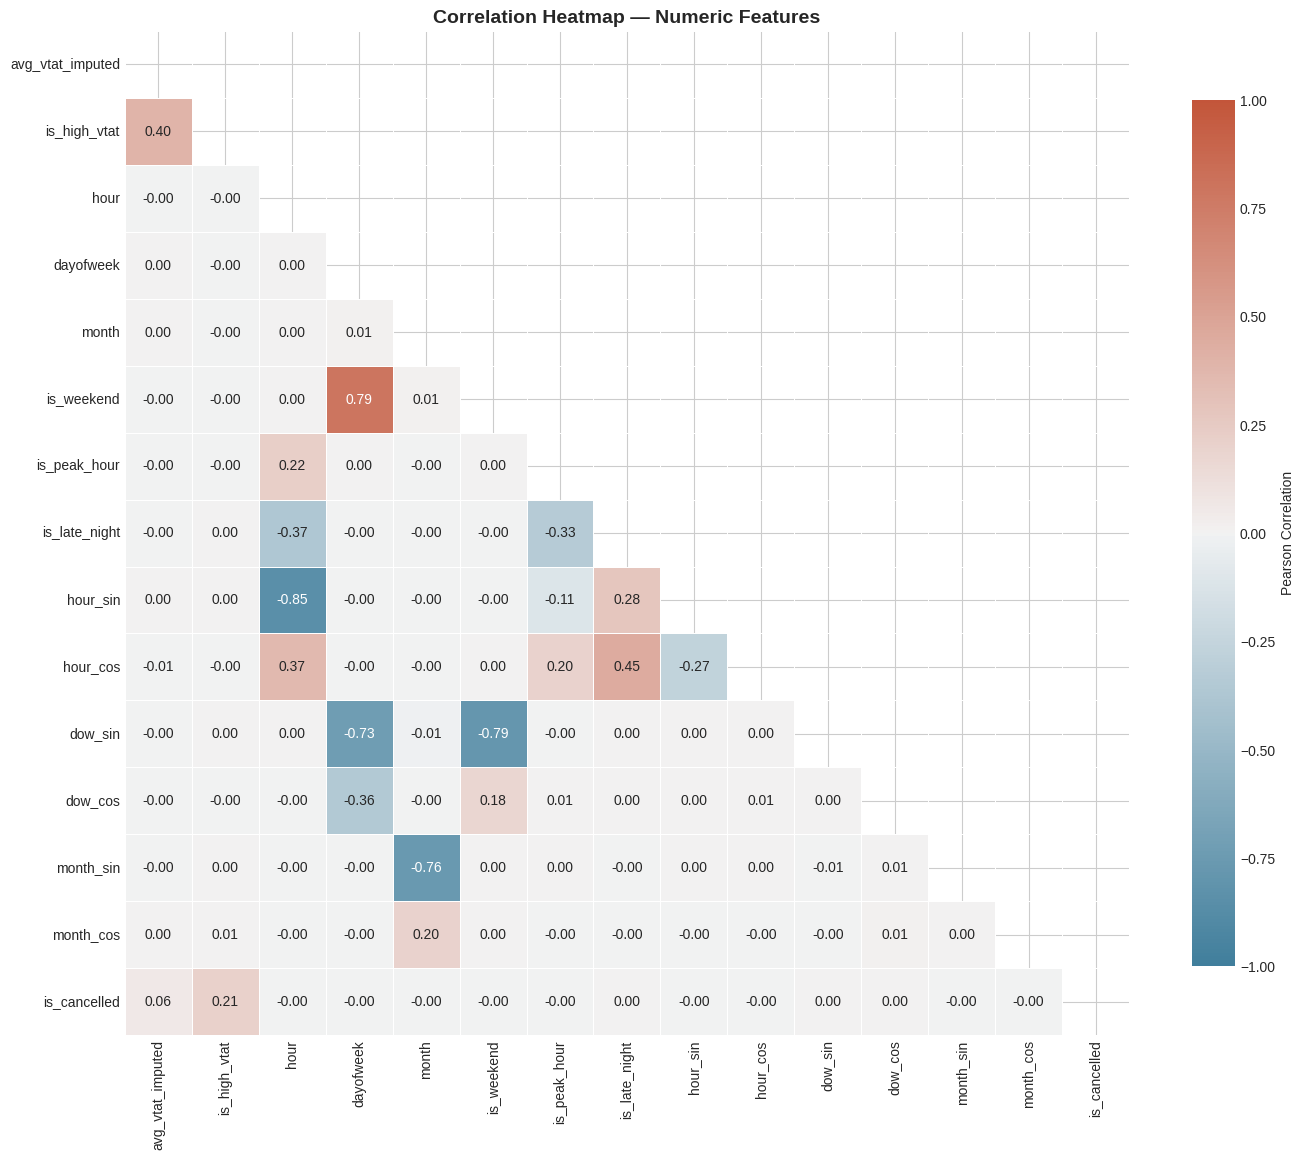


Feature pairs with |correlation| > 0.5:
  hour                      vs hour_sin                   r = -0.848
  dayofweek                 vs is_weekend                 r = +0.791
  dayofweek                 vs dow_sin                    r = -0.733
  month                     vs month_sin                  r = -0.765
  is_weekend                vs dow_sin                    r = -0.786


In [ ]:
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', square=True, linewidths=0.5,
    vmin=-1, vmax=1, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight strong correlations (|r| > 0.5) excluding self-correlations
print("\nFeature pairs with |correlation| > 0.5:")
print("=" * 60)
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr_matrix.columns[i]:25s} vs {corr_matrix.columns[j]:25s}  r = {r:+.3f}")

### 5.2 Variance Inflation Factor (VIF)

VIF measures how much a feature's variance is inflated by multicollinearity with other features. 

- **VIF = 1**: No multicollinearity
- **VIF = 1–5**: Moderate, generally acceptable
- **VIF = 5–10**: High multicollinearity, may need attention
- **VIF > 10**: Severe multicollinearity, consider removing or combining features

While Random Forest and XGBoost are robust to multicollinearity, checking VIF helps us understand which features carry redundant information and ensures that feature importance rankings are interpretable.

VARIANCE INFLATION FACTORS
  dayofweek                  VIF =    24.22  ⚠️ HIGH
  hour                       VIF =    18.40  ⚠️ HIGH
  is_weekend                 VIF =    10.97  ⚠️ HIGH
  month                      VIF =    10.46  ⚠️ HIGH
  avg_vtat_imputed           VIF =     6.91  ⚠️ HIGH
  hour_sin                   VIF =     3.13  ⚡ MODERATE
  dow_cos                    VIF =     2.96  ⚡ MODERATE
  is_peak_hour               VIF =     2.89  ⚡ MODERATE
  dow_sin                    VIF =     2.78  ⚡ MODERATE
  month_sin                  VIF =     2.35  ⚡ MODERATE
  is_late_night              VIF =     2.19  ⚡ MODERATE
  hour_cos                   VIF =     2.12  ⚡ MODERATE
  is_high_vtat               VIF =     1.21  ✅ OK
  month_cos                  VIF =     1.09  ✅ OK


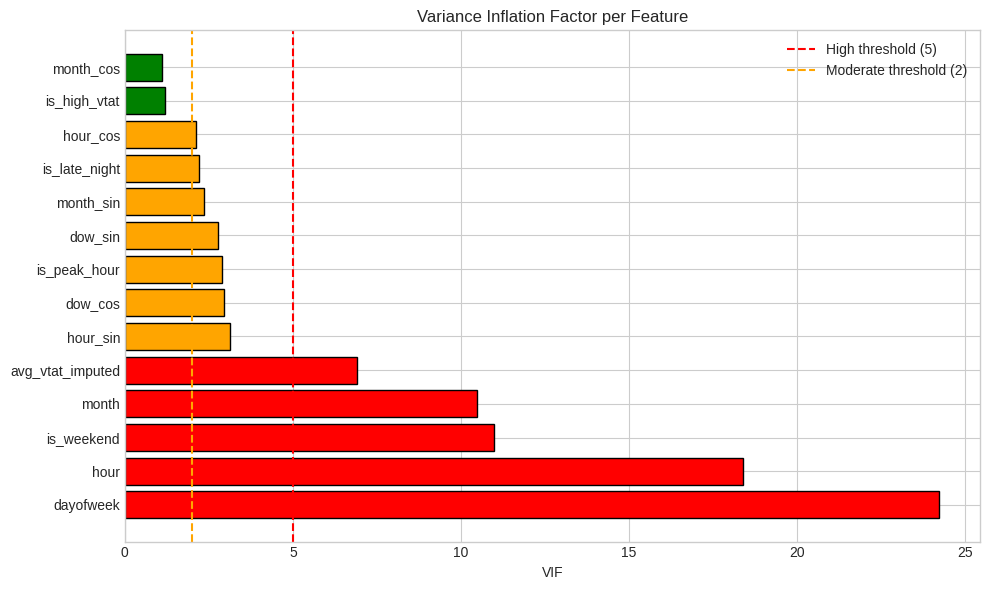

In [ ]:
# VIF on features only (exclude target)
feature_cols_for_vif = [c for c in NUMERIC_FEATURES if c != 'is_cancelled']
vif_data = numeric_df[feature_cols_for_vif].dropna()

vif_results = pd.DataFrame({
    'Feature': feature_cols_for_vif,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(feature_cols_for_vif))]
}).sort_values('VIF', ascending=False)

print("VARIANCE INFLATION FACTORS")
print("=" * 50)
for _, row in vif_results.iterrows():
    flag = "⚠️ HIGH" if row['VIF'] > 5 else ("⚡ MODERATE" if row['VIF'] > 2 else "✅ OK")
    print(f"  {row['Feature']:25s}  VIF = {row['VIF']:8.2f}  {flag}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v > 5 else ('orange' if v > 2 else 'green') for v in vif_results['VIF']]
ax.barh(vif_results['Feature'], vif_results['VIF'], color=colors, edgecolor='black')
ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='High threshold (5)')
ax.axvline(x=2, color='orange', linestyle='--', linewidth=1.5, label='Moderate threshold (2)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor per Feature')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Cramér's V — Categorical Feature Associations

Cramér's V quantifies the strength of association between two categorical variables (values range from 0 to 1):

- **0**: No association
- **0–0.1**: Negligible
- **0.1–0.3**: Weak
- **0.3–0.5**: Moderate
- **> 0.5**: Strong

This helps us understand whether categorical features (vehicle_type, locations, temporal categories) carry independent information or are redundant.

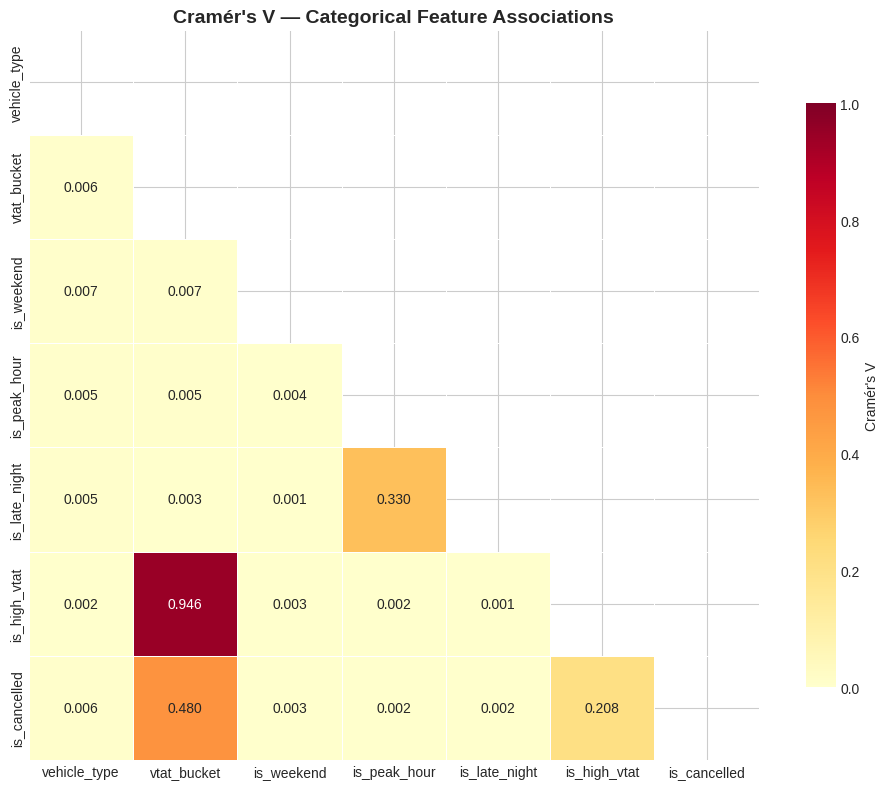


Cramér's V interpretation (excluding self-pairs):
  vtat_bucket          vs is_high_vtat          V = 0.946  (STRONG)
  vtat_bucket          vs is_cancelled          V = 0.480  (MODERATE)
  is_peak_hour         vs is_late_night         V = 0.330  (MODERATE)
  is_high_vtat         vs is_cancelled          V = 0.208  (WEAK)


In [ ]:
def cramers_v(x, y):
    """Compute Cramér's V statistic for two categorical Series."""
    confusion = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    min_dim = min(confusion.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Categorical columns to analyze
cat_cols = ['vehicle_type', 'vtat_bucket', 'is_weekend', 'is_peak_hour', 'is_late_night', 'is_high_vtat', 'is_cancelled']

# Compute pairwise Cramér's V
cramers_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    index=cat_cols, columns=cat_cols
)

for i, col_i in enumerate(cat_cols):
    for j, col_j in enumerate(cat_cols):
        if i == j:
            cramers_matrix.loc[col_i, col_j] = 1.0
        elif i < j:
            v = cramers_v(df[col_i].astype(str), df[col_j].astype(str))
            cramers_matrix.loc[col_i, col_j] = v
            cramers_matrix.loc[col_j, col_i] = v

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))
sns.heatmap(
    cramers_matrix.astype(float), mask=mask, annot=True, fmt='.3f',
    cmap='YlOrRd', vmin=0, vmax=1, square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Cramér's V"}
)
ax.set_title("Cramér's V — Categorical Feature Associations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight noteworthy pairs
print("\nCramér's V interpretation (excluding self-pairs):")
print("=" * 60)
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        v = cramers_matrix.iloc[i, j]
        strength = "STRONG" if v > 0.5 else ("MODERATE" if v > 0.3 else ("WEAK" if v > 0.1 else "NEGLIGIBLE"))
        if v > 0.1:
            print(f"  {cat_cols[i]:20s} vs {cat_cols[j]:20s}  V = {v:.3f}  ({strength})")

### 5.4 Feature Interaction Effects

Bivariate analysis showed that VTAT is the dominant predictor. But does VTAT interact with other features? For example:
- Does high VTAT cause more cancellations for certain vehicle types?
- Does the effect of VTAT change during peak hours vs. off-peak?
- Is there a location × VTAT interaction?

Understanding interactions helps us decide whether to create interaction features and explains why ensemble methods like RF/XGBoost may outperform linear models.

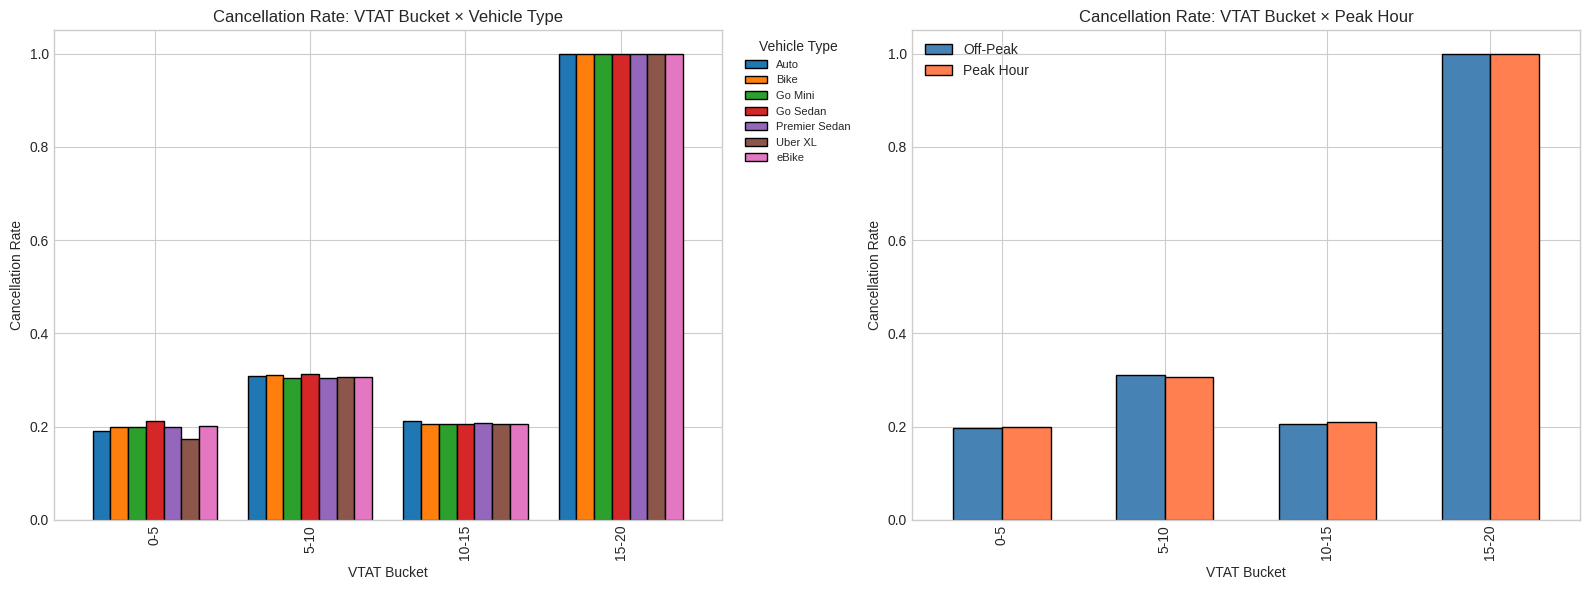


Key Observations:
------------------------------------------------------------
  VTAT 0-5: Vehicle type spread = 0.039 (max=Go Sedan: 21.15%, min=Uber XL: 17.27%)
  VTAT 5-10: Vehicle type spread = 0.008 (max=Go Sedan: 31.28%, min=Go Mini: 30.50%)
  VTAT 10-15: Vehicle type spread = 0.007 (max=Auto: 21.21%, min=Go Sedan: 20.49%)
  VTAT 15-20: Vehicle type spread = 0.000 (max=Auto: 100.00%, min=Auto: 100.00%)


In [ ]:
# --- Interaction 1: VTAT bucket × Vehicle Type ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cancellation rate: vtat_bucket × vehicle_type
interaction_1 = df.groupby(['vtat_bucket', 'vehicle_type'], observed=True)['is_cancelled'].mean().unstack()
interaction_1.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='black')
axes[0].set_title('Cancellation Rate: VTAT Bucket × Vehicle Type')
axes[0].set_xlabel('VTAT Bucket')
axes[0].set_ylabel('Cancellation Rate')
axes[0].legend(title='Vehicle Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].set_ylim(0, 1.05)

# Cancellation rate: vtat_bucket × peak_hour
interaction_2 = df.groupby(['vtat_bucket', 'is_peak_hour'], observed=True)['is_cancelled'].mean().unstack()
interaction_2.columns = ['Off-Peak', 'Peak Hour']
interaction_2.plot(kind='bar', ax=axes[1], width=0.6, color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Cancellation Rate: VTAT Bucket × Peak Hour')
axes[1].set_xlabel('VTAT Bucket')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("-" * 60)
for bucket in interaction_1.index:
    rates = interaction_1.loc[bucket]
    spread = rates.max() - rates.min()
    print(f"  VTAT {bucket}: Vehicle type spread = {spread:.3f} (max={rates.idxmax()}: {rates.max():.2%}, min={rates.idxmin()}: {rates.min():.2%})")

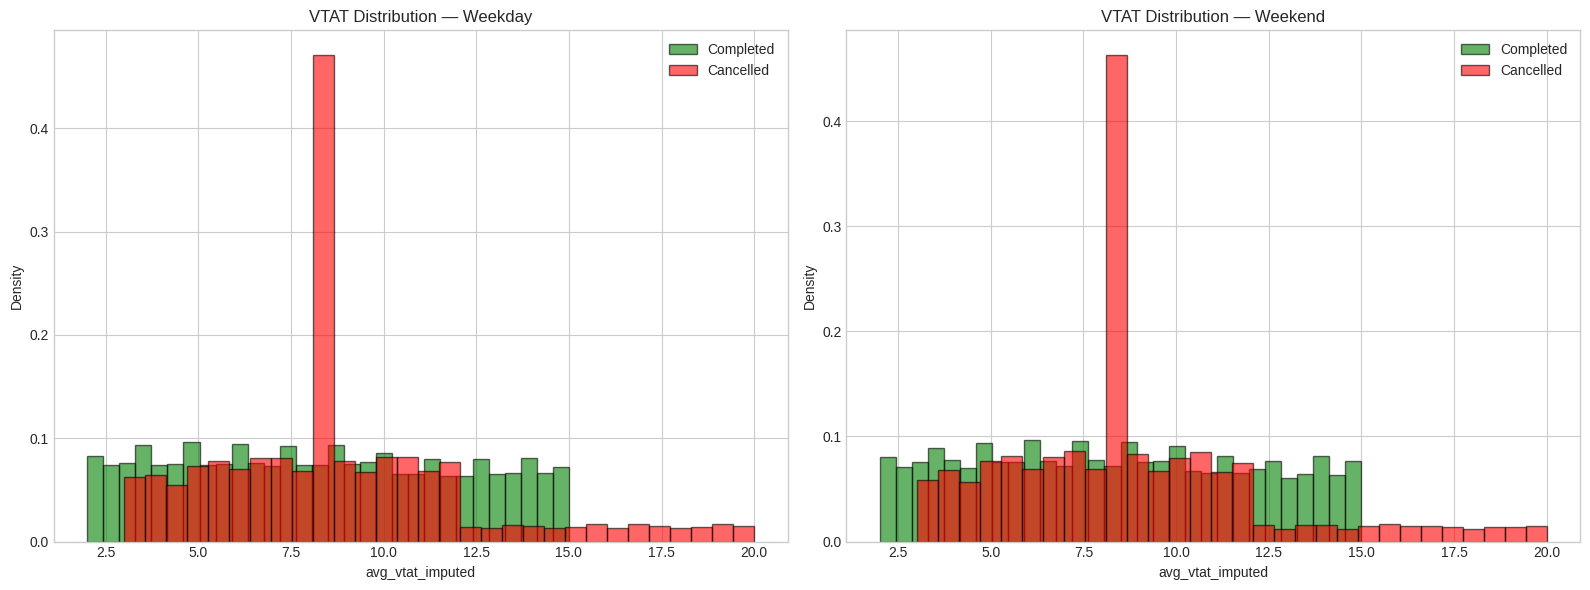

  Weekday: Point-biserial r = 0.0643, p = 1.75e-98
  Weekend: Point-biserial r = 0.0550, p = 3.86e-30


In [ ]:
# --- Interaction 2: VTAT × Weekend/Weekday ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VTAT distribution by cancellation status & weekend
for i, (weekend_val, label) in enumerate([(0, 'Weekday'), (1, 'Weekend')]):
    subset = df[df['is_weekend'] == weekend_val]
    cancelled = subset[subset['is_cancelled'] == 1]['avg_vtat_imputed']
    completed = subset[subset['is_cancelled'] == 0]['avg_vtat_imputed']
    
    axes[i].hist(completed, bins=30, alpha=0.6, label='Completed', color='green', density=True, edgecolor='black')
    axes[i].hist(cancelled, bins=30, alpha=0.6, label='Cancelled', color='red', density=True, edgecolor='black')
    axes[i].set_title(f'VTAT Distribution — {label}')
    axes[i].set_xlabel('avg_vtat_imputed')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Statistical comparison: VTAT effect on weekday vs weekend
for weekend_val, label in [(0, 'Weekday'), (1, 'Weekend')]:
    subset = df[df['is_weekend'] == weekend_val]
    corr, pval = stats.pointbiserialr(subset['is_cancelled'], subset['avg_vtat_imputed'])
    print(f"  {label}: Point-biserial r = {corr:.4f}, p = {pval:.2e}")

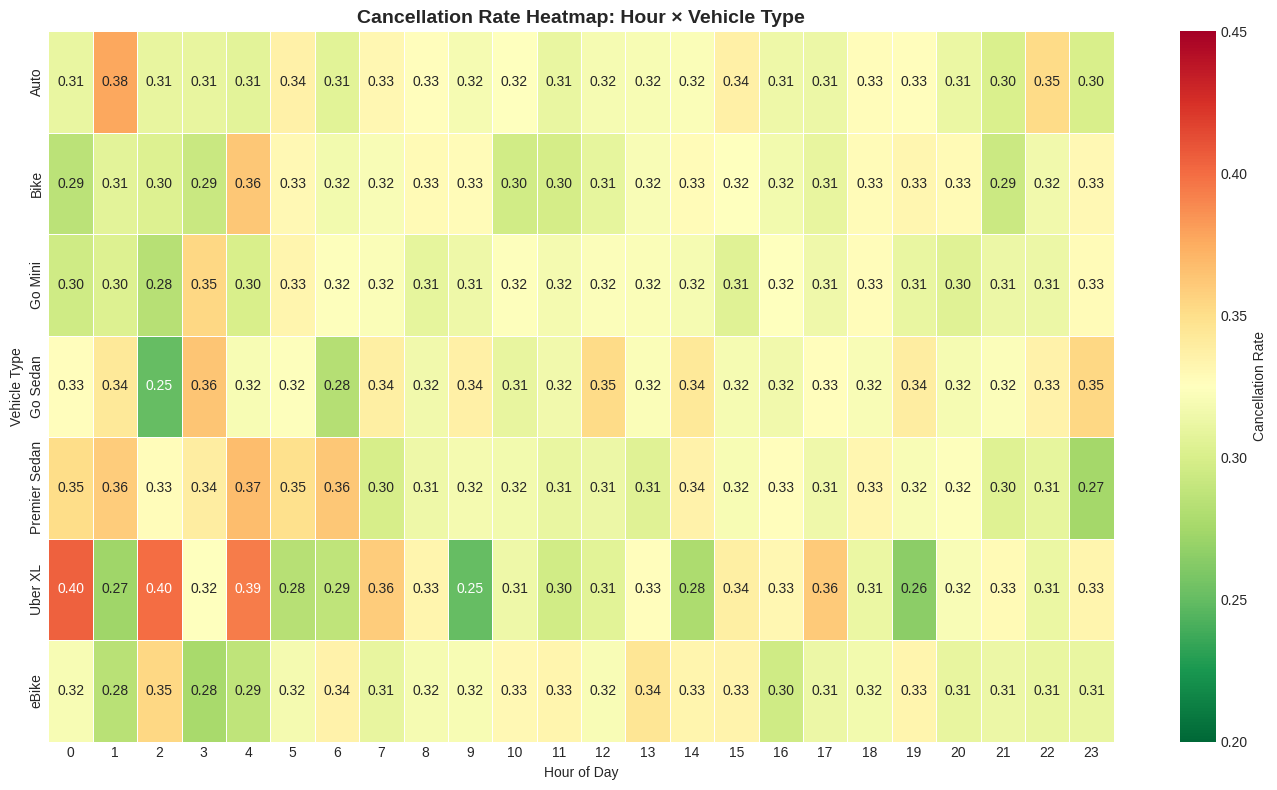

In [ ]:
# --- Interaction 3: Hour × Vehicle Type Cancellation Heatmap ---
hourly_vehicle = df.groupby(['hour', 'vehicle_type'], observed=True)['is_cancelled'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    hourly_vehicle.T, cmap='RdYlGn_r', annot=True, fmt='.2f',
    linewidths=0.5, ax=ax, vmin=0.20, vmax=0.45,
    cbar_kws={"label": "Cancellation Rate"}
)
ax.set_title('Cancellation Rate Heatmap: Hour × Vehicle Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Vehicle Type')
plt.tight_layout()
plt.show()

### 5.5 Mutual Information — Non-Linear Feature Relevance

Mutual Information (MI) captures both linear and non-linear dependencies between each feature and the target. Unlike Pearson correlation, MI can detect any type of statistical dependence. Higher MI means the feature carries more information about the target.

This is particularly relevant for tree-based models which can exploit non-linear patterns.

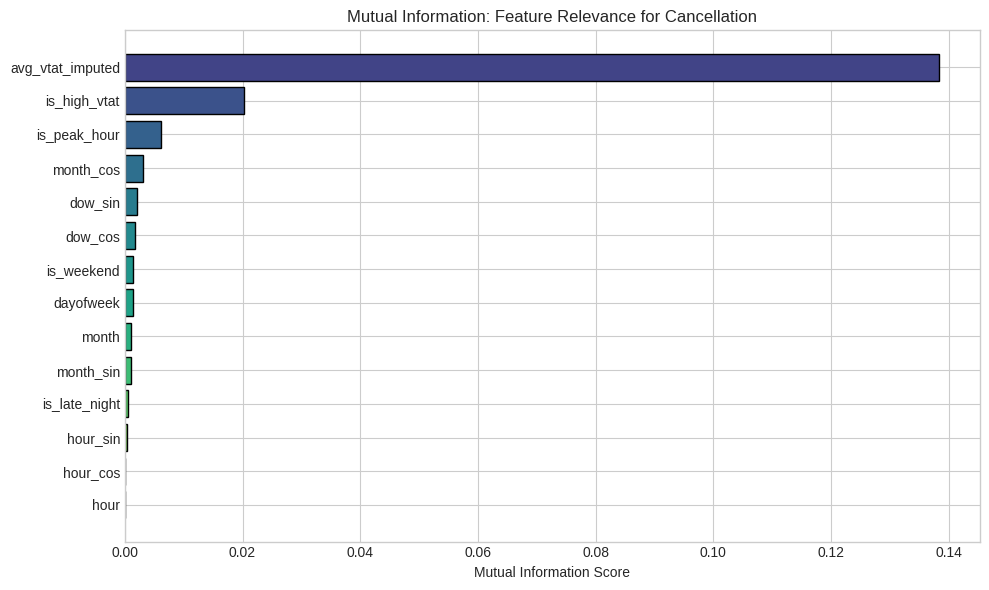


Mutual Information Ranking:
  avg_vtat_imputed           MI = 0.1384  ███████████████████████████
  is_high_vtat               MI = 0.0202  ████
  is_peak_hour               MI = 0.0061  █
  month_cos                  MI = 0.0031  
  dow_sin                    MI = 0.0021  
  dow_cos                    MI = 0.0017  
  is_weekend                 MI = 0.0014  
  dayofweek                  MI = 0.0014  
  month                      MI = 0.0010  
  month_sin                  MI = 0.0010  
  is_late_night              MI = 0.0005  
  hour_sin                   MI = 0.0004  
  hour_cos                   MI = 0.0000  
  hour                       MI = 0.0000  


In [ ]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = [c for c in NUMERIC_FEATURES if c != 'is_cancelled']
X_mi = numeric_df[feature_cols].dropna()
y_mi = numeric_df.loc[X_mi.index, 'is_cancelled']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({
    'Feature': feature_cols,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(mi_df)))
ax.barh(mi_df['Feature'], mi_df['MI Score'], color=colors, edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information: Feature Relevance for Cancellation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nMutual Information Ranking:")
print("=" * 50)
for _, row in mi_df.iterrows():
    bar = "█" * int(row['MI Score'] * 200)
    print(f"  {row['Feature']:25s}  MI = {row['MI Score']:.4f}  {bar}")

### 5.6 Model Assumption Validation

We are planning to use **Random Forest**, **XGBoost** and **LightGBM** — all tree-based ensemble methods. Let's check their key assumptions:

| Assumption | RF/XGBoost/LightGBM | Check |
|------------|---------------------|-------|
| Linearity | NOT required | Tree-based models handle non-linear relationships natively |
| Normality | NOT required | No distributional assumptions on features |
| Homoscedasticity | NOT required | Variance equality is irrelevant for tree splits |
| Feature scale | NOT sensitive | Trees split on rank-order, not magnitude |
| Multicollinearity | Robust but affects interpretability | Checked above via VIF |
| Class balance | Sensitive | Need to verify and handle via class_weight or sampling |
| Sufficient data | Required | Need enough samples per class |
| Feature independence | NOT required | Trees naturally capture interactions |

**Key checks below:** class separability, class balance, and whether features have enough variance.

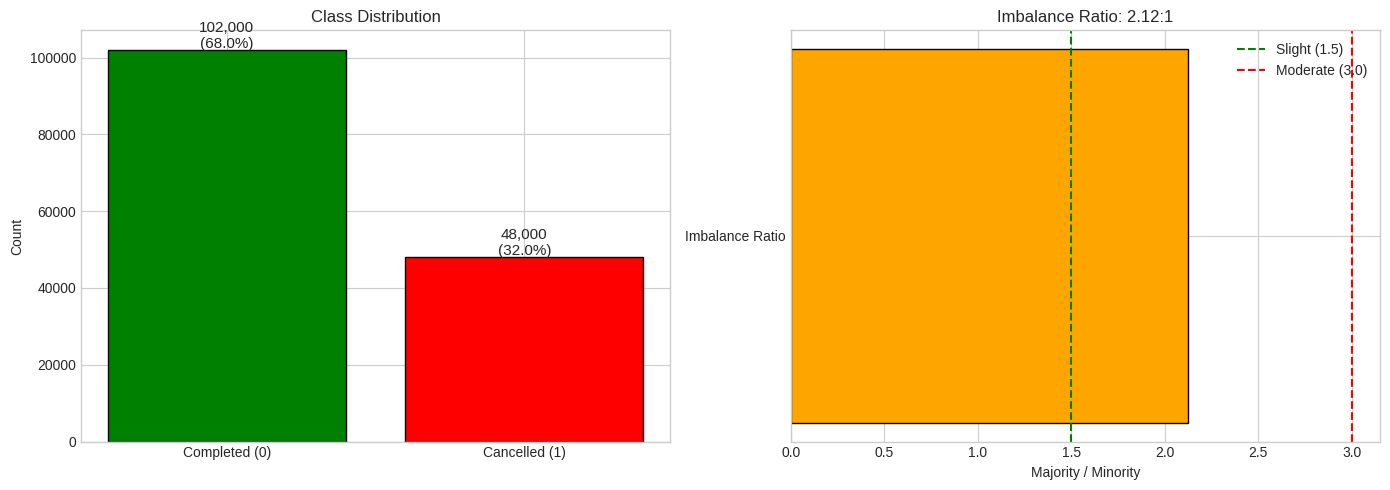


Class balance summary:
  Completed: 102,000 (68.0%)
  Cancelled: 48,000 (32.0%)
  Ratio:     2.12:1

  → Moderate imbalance. Will use class_weight='balanced' and threshold tuning.


In [ ]:
# --- Class Balance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['is_cancelled'].value_counts()
class_labels = ['Completed (0)', 'Cancelled (1)']

axes[0].bar(class_labels, class_counts.values, color=['green', 'red'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
for i, (label, count) in enumerate(zip(class_labels, class_counts.values)):
    axes[0].text(i, count + 500, f'{count:,}\n({count/len(df):.1%})', ha='center', fontsize=11)

# Imbalance ratio
majority = class_counts.max()
minority = class_counts.min()
ratio = majority / minority

axes[1].barh(['Imbalance Ratio'], [ratio], color='orange', edgecolor='black')
axes[1].set_xlabel('Majority / Minority')
axes[1].set_title(f'Imbalance Ratio: {ratio:.2f}:1')
axes[1].axvline(x=1.5, color='green', linestyle='--', label='Slight (1.5)')
axes[1].axvline(x=3.0, color='red', linestyle='--', label='Moderate (3.0)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nClass balance summary:")
print(f"  Completed: {class_counts[0.0]:,} ({class_counts[0.0]/len(df):.1%})")
print(f"  Cancelled: {class_counts[1.0]:,} ({class_counts[1.0]/len(df):.1%})")
print(f"  Ratio:     {ratio:.2f}:1")
print(f"\n  → Moderate imbalance. Will use class_weight='balanced' and threshold tuning.")

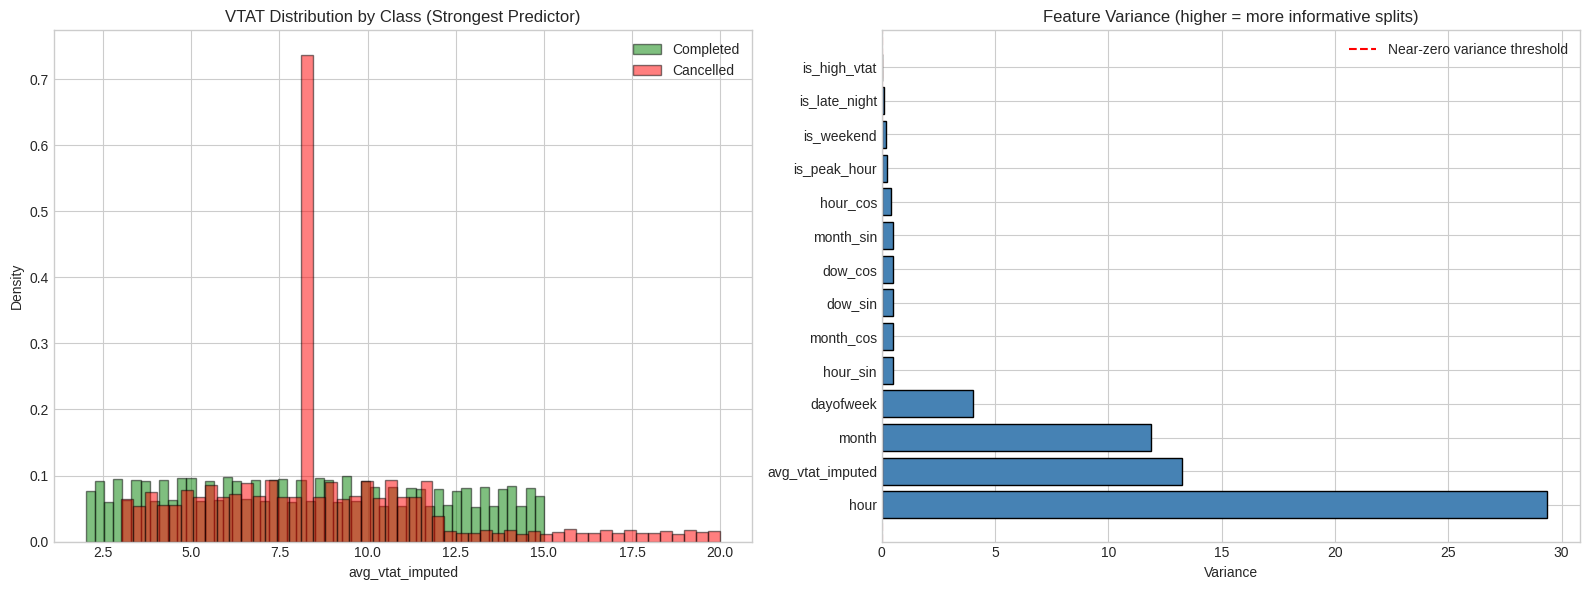


✅ All features have sufficient variance for tree splits.


In [ ]:
# --- Class Separability: VTAT distribution by class ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE of VTAT by class
for cls, color, label in [(0, 'green', 'Completed'), (1, 'red', 'Cancelled')]:
    subset = df[df['is_cancelled'] == cls]['avg_vtat_imputed']
    axes[0].hist(subset, bins=50, alpha=0.5, density=True, color=color, label=label, edgecolor='black')
axes[0].set_title('VTAT Distribution by Class (Strongest Predictor)')
axes[0].set_xlabel('avg_vtat_imputed')
axes[0].set_ylabel('Density')
axes[0].legend()

# Feature variance check
feature_vars = numeric_df[feature_cols].var().sort_values(ascending=False)
axes[1].barh(feature_vars.index, feature_vars.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Variance')
axes[1].set_title('Feature Variance (higher = more informative splits)')
axes[1].axvline(x=0.01, color='red', linestyle='--', label='Near-zero variance threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify near-zero variance features
low_var = feature_vars[feature_vars < 0.01]
if len(low_var) > 0:
    print(f"\n⚠️ Features with near-zero variance (< 0.01):")
    for feat, var in low_var.items():
        print(f"    {feat}: variance = {var:.6f}")
else:
    print("\n✅ All features have sufficient variance for tree splits.")

In [ ]:
# --- Missing value summary for modeling readiness ---
print("MISSING VALUE SUMMARY — Full Dataset")
print("=" * 60)
missing = df[NUMERIC_FEATURES + ['vehicle_type', 'pickup_location', 'drop_location']].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_summary) > 0:
    print(missing_summary)
    print(f"\n  → avg_vtat has {missing_summary.loc['avg_vtat_imputed', 'Missing %'] if 'avg_vtat_imputed' in missing_summary.index else 0}% missing")
    print("  → Will impute using median by vehicle_type (preserves within-group distribution)")
else:
    print("  ✅ No missing values in the feature matrix after imputation.")

MISSING VALUE SUMMARY — Full Dataset
  ✅ No missing values in the feature matrix after imputation.


## 6. EDA Summary & Implications for Modeling

### Key Findings

**Bivariate Analysis (Feature → Target):**
| Feature | Predictive Strength | Evidence |
|---------|-------------------|----------|
| `avg_vtat` | **STRONG** | Point-biserial r ≈ 0.072, 100% cancellation when VTAT > 15 min, statistically significant t-test |
| `vehicle_type` | **WEAK** | All types ≈ 32% cancellation, chi-square not significant |
| Temporal features | **WEAK** | Flat cancellation rates across hours, days, months |
| `pickup/drop_location` | **MODERATE** | Range 28–39% across 176 locations, high cardinality |

**Multivariate Analysis (Feature ↔ Feature):**
| Check | Result | Action |
|-------|--------|--------|
| Correlation heatmap | Expected correlations between raw & cyclical encodings of the same variable | Keep both: raw for trees, cyclical for potential linear baselines |
| VIF | `hour`/`hour_sin`/`hour_cos` and similar pairs may show moderate VIF | Acceptable for tree-based models; monitor feature importance |
| Cramér's V | `vtat_bucket` and `is_high_vtat` are related (by construction) | Expected — both derive from VTAT |
| Feature interactions | VTAT effect is consistent across vehicle types and time periods | No strong interaction terms needed beyond VTAT itself |
| Mutual Information | VTAT dominates; temporal and location features carry weak signal | Confirms bivariate findings with non-linear measure |

**Model Assumption Checks:**
| Assumption | Status | Notes |
|------------|--------|-------|
| Class balance | ⚠️ Moderate imbalance (~2:1) | Use `class_weight='balanced'` + threshold tuning |
| Class separability | ✅ Clear separation via VTAT | VTAT > 15 = near-certain cancellation |
| Feature variance | ✅ Sufficient for all features | No near-zero variance issues |
| Missing values | ⚠️ `avg_vtat` has 7% missing | Impute with median by vehicle_type |

### Implications for Feature Engineering
1. **VTAT is the star feature** — create `avg_vtat_imputed`, `vtat_bucket`, `is_high_vtat`
2. **Location needs encoding** — 176 unique values → target encoding with smoothing
3. **Vehicle type** is weak but cheap to include → label encoding
4. **Temporal features** are weak individually but may help in ensemble splits → include cyclical + binary encodings
5. **No strong interactions** justify complex interaction features for v1

### Implications for Model Selection
- **Tree-based models are ideal**: no normality/linearity assumptions, robust to multicollinearity, handle mixed feature types, can capture non-linear VTAT threshold effect
- **Class imbalance handling** is critical: use balanced class weights + F2-optimized threshold
- **Feature importance will be dominated by VTAT** — this is expected and validated by both correlation and mutual information analysis